In [38]:
import numpy as np
import matplotlib.pyplot as pl
%matplotlib inline
import jax.numpy as jnp
import jax



In [39]:
x_obs_array = jnp.logspace(-1, 1, 10)


In [151]:
# y = a*b^2*x + n1
# y = (a/b)*(1/x) + n2


a_fid = 0.15
b_fid = 0.15

y_fid1 = a_fid*(b_fid**2)*x_obs_array
y1_noise_fac = 0.75
y_obs1 = y_fid1 + jax.random.normal(jax.random.PRNGKey(0),len(x_obs_array))*(y1_noise_fac*y_fid1)

# y_fid2 = a_fid/(b_fid)*(1/x_obs_array)
# y_fid2 = a_fid/(b_fid)*(x_obs_array)
y_fid2 = (a_fid*b_fid)*(x_obs_array)
y2_noise_fac = 0.75
y_obs2 = y_fid2 + jax.random.normal(jax.random.PRNGKey(0),len(x_obs_array))*(y2_noise_fac*y_fid2)

y_obs_tot = jnp.concatenate([y_obs1, y_obs2])


In [152]:
# pl.figure()
# pl.plot(y_obs_tot)
# pl.yscale('log')


In [153]:
from jax import jit, vmap

@jit
def get_obs(js):
    y_obs1_js = y_fid1 + jax.random.normal(jax.random.PRNGKey(js),len(x_obs_array))*(y1_noise_fac*y_fid1)
    y_obs2_js = y_fid2 + jax.random.normal(jax.random.PRNGKey(js),len(x_obs_array))*(y2_noise_fac*y_fid2)
    y_obs_tot = jnp.concatenate((y_obs1_js, y_obs2_js))
    return y_obs_tot
    


In [154]:
obs_all = vmap(get_obs)(jnp.arange(5000000))
obs_cov0 = jnp.cov(obs_all.T)
obs_cov = jnp.diag(jnp.diag(obs_cov0))


In [155]:
# jnp.linalg.eig(obs_cov)


/tmp/ipykernel_3797337/1463516588.py:12: RuntimeWarning: divide by zero encountered in log
  pl.imshow(np.log(np.abs(obs_cov)), origin='lower')


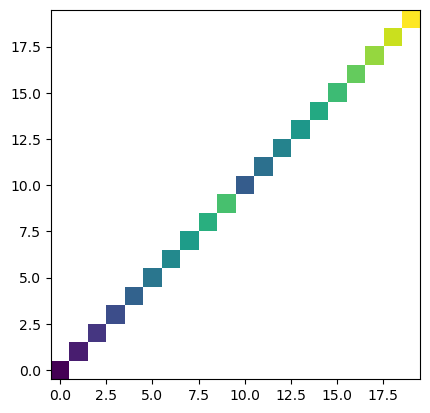

In [156]:
# obs_cov = np.block([
#     [obs_cov_b1, obs_cov_b3],
#     [obs_cov_b4, obs_cov_b2]
# ])
# obs_cov = jnp.array(obs_cov)

# obs_cov = np.diag(np.diag(obs_cov0))
# obs_cov[0:len(y_obs1),len(y_obs1):len(y_obs_tot)] = obs_cov0[0:len(y_obs1),len(y_obs1):len(y_obs_tot)]
# obs_cov[len(y_obs1):len(y_obs_tot), 0:len(y_obs1)] = obs_cov0[len(y_obs1):len(y_obs_tot), 0:len(y_obs1)]
# obs_cov.shape
pl.figure()
pl.imshow(np.log(np.abs(obs_cov)), origin='lower')





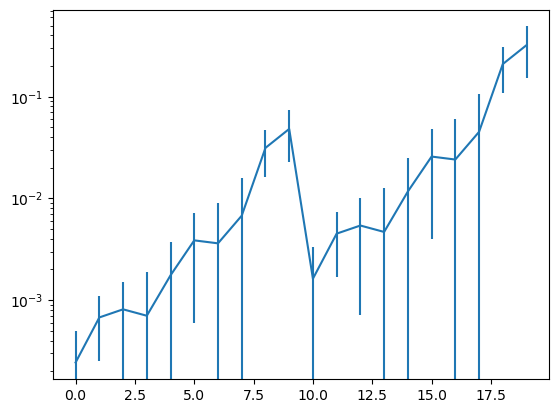

In [157]:
sig_all = np.sqrt(np.diag(obs_cov))
# sig_all
pl.figure()
pl.errorbar(np.arange(len(sig_all)),y_obs_tot, sig_all)
pl.yscale('log')



In [158]:
import numpyro.distributions as dist
def model():
    a = numpyro.sample('a',dist.Uniform(0.1, 0.2))
    b = numpyro.sample('b',dist.Uniform(0.1, 0.2))
    y1 = a*(b**2)*x_obs_array
    # y2 = a/(b)*(1/x_obs_array)
    # y2 = a/(b)*(x_obs_array)    
    y2 = (a*b)*(x_obs_array)    
    ytot = jnp.concatenate([y1, y2])
    # return ytot
    return numpyro.sample('cl', dist.MultivariateNormal(ytot, 
                                                            covariance_matrix=obs_cov))



In [159]:
import numpyro
numpyro.set_host_device_count(1)
from numpyro.handlers import seed, trace, condition
observed_model = condition(model, {'cl': y_obs_tot})




In [160]:
nuts_kernel = numpyro.infer.NUTS(observed_model,
                            step_size=2e-1, 
                            init_strategy=numpyro.infer.init_to_median,
                            dense_mass=True,
                            max_tree_depth=5
                            )



In [161]:
num_warmup = 60000
num_samples = 60000
num_chains= 8
mcmc = numpyro.infer.MCMC(nuts_kernel, 
                        num_warmup=num_warmup, 
                        num_samples=num_samples,
                        num_chains=num_chains,
                        chain_method='vectorized',
                        #   chain_method='sequential',                          
                        progress_bar=True,
                        jit_model_args=True)




In [162]:
# n_parallel = jax.local_device_count()
# rng_keys = jax.random.split(jax.random.PRNGKey(42), n_parallel)
mcmc.run(jax.random.PRNGKey(0))


sample: 100%|██████████| 120000/120000 [03:13<00:00, 618.90it/s]


In [163]:
# samps['a'].shape




In [164]:
samps = mcmc.get_samples()




In [165]:
samps_hmc = np.array([samps['a'], samps['b']]).T



In [166]:
samps_hmc.shape


(480000, 2)

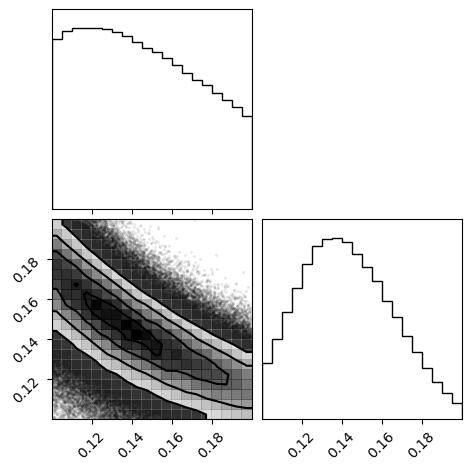

In [167]:
import corner
figure = corner.corner(np.array([samps['a'], samps['b']]).T)




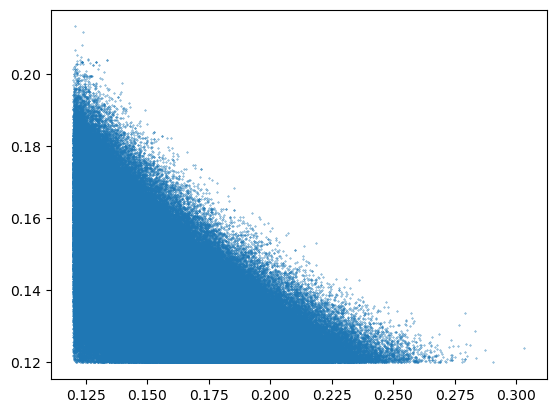

In [112]:
# samps['a']
pl.figure()
pl.scatter(samps['a'], samps['b'], s=0.1)



In [168]:
import jax
a_fid = 0.15
b_fid = 0.15

def get_model_fid(a):
    y_fid1 = a*(b_fid**2)*x_obs_array
    # y_fid2 = a/(b_fid)*(1/x_obs_array)
    # y_fid2 = a/(b_fid)*(x_obs_array)    
    y_fid2 = (a*b_fid)*(x_obs_array)    
    y_tot = jnp.concatenate([y_fid1, y_fid2])
    return y_tot

jac_mean = jax.jit(jax.jacfwd(get_model_fid))
dmu_a = jac_mean(a_fid)


In [169]:
def get_model_fid(b):
    y_fid1 = a_fid*(b**2)*x_obs_array
    # y_fid2 = a_fid/(b)*(1/x_obs_array)
    # y_fid2 = a_fid/(b)*(x_obs_array)    
    y_fid2 = (a_fid*b)*(x_obs_array)    
    y_tot = jnp.concatenate([y_fid1, y_fid2])
    return y_tot

jac_mean = jax.jit(jax.jacfwd(get_model_fid))
dmu_b = jac_mean(b_fid)



In [170]:
P = jnp.linalg.inv(obs_cov)
dmu_all = np.array([dmu_a, dmu_b]).T
F_all = jnp.matmul(dmu_all.T, jnp.matmul(P, dmu_all))
cov_params = np.linalg.inv(F_all)


In [171]:
# dmu_all[None,:].shape



In [178]:
samps_fish = np.random.multivariate_normal(np.array([a_fid, b_fid]), cov_params, 1000000)




In [179]:

import getdist
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import MixtureND

import matplotlib
%matplotlib inline





In [180]:
settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.1, 'smooth_scale_2D': 0.1}
chain_fish = MCSamples(samples=samps_fish, names=['a','b'],
                           labels=['a','b'], name_tag=r'Fisher',settings=settings)

chain_hmc = MCSamples(samples=samps_hmc, names=['a','b'],
                           labels=['a','b'], name_tag=r'HMC',settings=settings)



Removed no burn in
Removed no burn in


((np.float64(-0.15796920635770367), np.float64(0.45934725881829974)),
 (np.float64(-0.04537306351147749), np.float64(0.3450501417256191)))

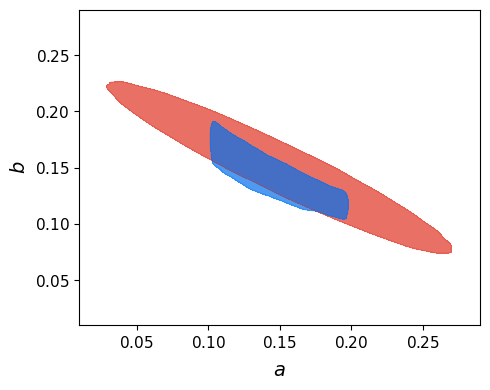

In [181]:
g = plots.get_single_plotter(width_inch=5, ratio=0.8)
g.settings.num_plot_contours = 1

# g.triangle_plot([chain_Y1, chain_Y6], params=chain_Y1.getParamNames().list()[:2], filled=True)
contour_args = {'filled': True, 'alpha': 0.7}
# g.plot_2d([chain_Y1, chain_Y6], 'theta_ej_0', 'mu_beta', filled=True, contour_args=contour_args, lims=[-3.0, 11.0, -0.2, 0.6])
g.plot_2d([chain_fish, chain_hmc], 'a', 'b', filled=True, contour_args=contour_args, lims=[0.01, 0.29, 0.01, 0.29])
# g.export('/mnt/home/spandey/ceph/GODMAX/notebooks/plots/theta_ej_0_mu_beta_forecast.pdf')




In [140]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as pl
def plot_contours(fisher, pos, inds=[1,0], nstd=1., ax=None, **kwargs):
  """
  Plot 2D parameter contours given a Hessian matrix of the likelihood
  """
  i,j = inds
  
  def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:, order]

  mat = fisher
  cov = np.linalg.inv(mat)
  sigma_marg = lambda i: np.sqrt(cov[i, i])

  if ax is None:
      ax = pl.gca()

  # Extracts the block we are interested in
  block_cov = cov[:,[i,j]][[i,j],:]
  vals, vecs = eigsorted(block_cov)
  theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

  # Width and height are "full" widths, not radius
  width, height = 2 * nstd * np.sqrt(vals)
  ellip = Ellipse(xy=pos[[i,j]], width=width,
                  height=height, angle=theta, **kwargs)

  ax.add_artist(ellip)
  sz = max(width, height)
  s1 = 1.5*nstd*sigma_marg(i)
  s2 = 1.5*nstd*sigma_marg(j)
  ax.set_xlim(pos[i] - s1, pos[i] + s1)
  ax.set_ylim(pos[j] - s2, pos[j] + s2)
  pl.draw()
  return ellip



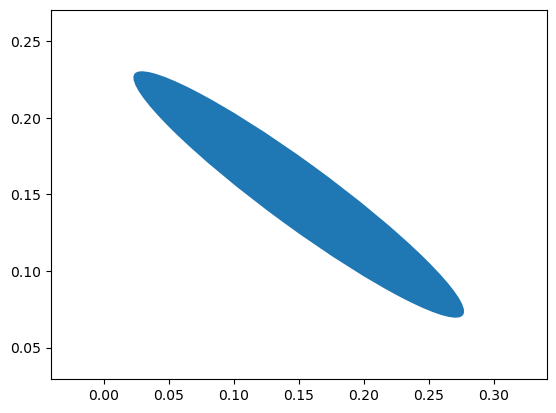

In [141]:
plot_contours(F_all, np.array([a_fid, b_fid]), inds=[0,1], nstd=2.,)



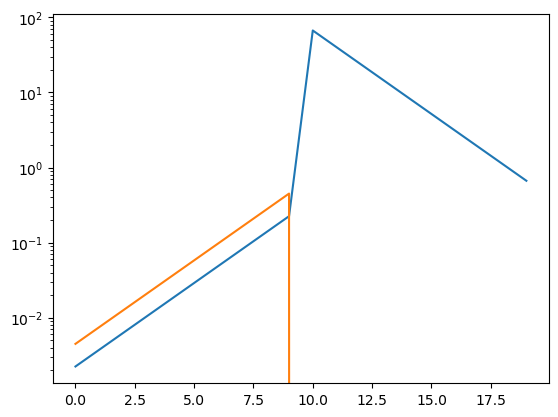

In [30]:
pl.figure()
pl.plot(np.arange(len(y_obs_tot)), dmu_a)
pl.plot(np.arange(len(y_obs_tot)), dmu_b)
pl.yscale('log')

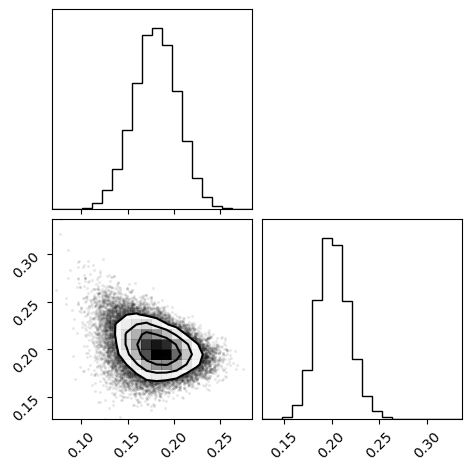

In [287]:
import corner
figure = corner.corner(np.array([samps['a'], samps['b']]).T)
